# EDA for train.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set(style="whitegrid")
%matplotlib inline

# Understanding the task
The aim of this competition is to predict the Severity Impairment Index (sii), which measures the level of problematic internet use among children and adolescents, based on physical activity data and other features.

sii is derived from PCIAT-PCIAT_Total, the sum of scores from the Parent-Child Internet Addiction Test (PCIAT: 20 questions, scored 0-5).

Target Variable (sii) is defined as:

- 0: None (PCIAT-PCIAT_Total from 0 to 30)
- 1: Mild (PCIAT-PCIAT_Total from 31 to 49)
- 2: Moderate (PCIAT-PCIAT_Total from 50 to 79)
- 3: Severe (PCIAT-PCIAT_Total 80 and more)

This makes sii an ordinal categorical variable with four levels, where the order of categories is meaningful.

Type of Machine Learning Problem we can use with sii as a target:

- Ordinal classification (ordinal logistic regression, models with custom ordinal loss functions)
- Multiclass classification (treat sii as a nominal categorical variable without considering the order)
- Regression (ignore the discrete nature of categories and treat sii as a continuous variable, then round prediction)
- Custom (e.g. loss functions that penalize errors based on the distance between categories)

We can also use PCIAT-PCIAT_Total as a continuous target variable, and implement regression on PCIAT-PCIAT_Total and then map predictions to sii categories.

## Data Preview

In [4]:
train = pd.read_csv('../data/child-mind-institute-problematic-internet-use/train.csv')
test = pd.read_csv('../data/child-mind-institute-problematic-internet-use/test.csv')
data_dict = pd.read_csv('../data/child-mind-institute-problematic-internet-use/data_dictionary.csv')

Train data

In [5]:
display(train.head())
print(f"Train shape: {train.shape}")

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Train shape: (3960, 82)


Test Data

In [6]:
display(test.head())
print(f"Test shape: {test.shape}")

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,32.6909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,27.0552,NaN,NaN,Fall,2.340,Fall,46.0,64.0,Summer,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,NaN,NaN,NaN,Summer,2.170,Fall,38.0,54.0,Summer,2.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,45.9966,NaN,NaN,Winter,2.451,Summer,31.0,45.0,Winter,0.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Test shape: (20, 59)


Data Dictinary

In [7]:
data_dict.head()

,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN


Let's identify the features that are related to the target variable and that are not present in the test set.

In [8]:
train_cols = set(train.columns)
test_cols = set(test.columns)
columns_not_in_test  = sorted(list(train_cols - test_cols))
data_dict[data_dict['Field'].isin(columns_not_in_test)]

,Instrument,Field,Description,Type,Values,Value Labels
54,Parent-Child Internet Addiction Test,PCIAT-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
55,Parent-Child Internet Addiction Test,PCIAT-PCIAT_01,How often does your child disobey time limits ...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
56,Parent-Child Internet Addiction Test,PCIAT-PCIAT_02,How often does your child neglect household ch...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
57,Parent-Child Internet Addiction Test,PCIAT-PCIAT_03,How often does your child prefer to spend time...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
58,Parent-Child Internet Addiction Test,PCIAT-PCIAT_04,How often does your child form new relationshi...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
59,Parent-Child Internet Addiction Test,PCIAT-PCIAT_05,How often do you complain about the amount of ...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
60,Parent-Child Internet Addiction Test,PCIAT-PCIAT_06,How often do your child's grades suffer becaus...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
61,Parent-Child Internet Addiction Test,PCIAT-PCIAT_07,How often does your child check his or her e-m...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
62,Parent-Child Internet Addiction Test,PCIAT-PCIAT_08,How often does your child seem withdrawn from ...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."
63,Parent-Child Internet Addiction Test,PCIAT-PCIAT_09,How often does your child become defensive or ...,categorical int,"0,1,2,3,4,5","0=Does Not Apply, 1=Rarely, 2=Occasionally, 3=..."


**Parent-Child Internet Addiction Test (PCIAT)**: contains 20 items (PCIAT-PCIAT_01 to PCIAT-PCIAT_20), each assessing a different aspect of a child's behavior related to internet use. The items are answered on a scale (from 0 to 5), and the total score provides an indication of the severity of internet addiction.

We also have season of participation in PCIAT-Season and total Score in PCIAT-PCIAT_Total; so there are 22 PCIAT test-related columns in total.

Let's verify that the PCIAT-PCIAT_Total align with the corresponding sii categories by calculating its minimum and maximum scores for each sii category:

In [9]:
pciat_min_max = train.groupby('sii')['PCIAT-PCIAT_Total'].agg(['min', 'max'])
pciat_min_max = pciat_min_max.rename(columns={'min': 'Minimum PCIAT total Score', 'max': 'Maximum total PCIAT Score'})
pciat_min_max

,Minimum PCIAT total Score,Maximum total PCIAT Score
sii,,
0.0,0.0,30.0
1.0,31.0,49.0
2.0,50.0,79.0
3.0,80.0,93.0


In [10]:
data_dict[data_dict['Field'] == 'PCIAT-PCIAT_Total']['Value Labels'].iloc[0]

'Severity Impairment Index: 0-30=None; 31-49=Mild; 50-79=Moderate; 80-100=Severe'

## Checking missing answers

In [11]:
train_with_sii = train[train['sii'].notna()][columns_not_in_test]
train_with_sii[train_with_sii.isna().any(axis=1)].head().style.applymap(
    lambda x: 'background-color: #FFC0CB' if pd.isna(x) else ''
)

,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,PCIAT-Season,sii
24,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,nan,2.000000,30.000000,Summer,0.000000
93,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,Fall,0.000000
104,5.000000,2.000000,4.000000,2.000000,nan,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,45.000000,Fall,1.000000
141,1.000000,2.000000,4.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,nan,0.000000,2.000000,0.000000,26.000000,Winter,0.000000
142,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,3.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,nan,1.000000,26.000000,Spring,0.000000


For example, in the 1st and 3rd rows you can see that the score for one answer is missing. And since each question is scored from 1 to 5, the total score could be up to 5 points higher and correspond to the next SII category (SII can be 0 or 1 for the first row and 1 or 2 for the third). For the second row, PCIAT-PCIAT_Total and sii appears to have been filled in by mistake, as there are no test questions answered at all.

Let's check if PCIAT-PCIAT_Total was indeed calculated as a sum of non-NA values in PCIAT-PCIAT_01 to PCIAT-PCIAT_20 columns:

In [12]:
PCIAT_cols = [f'PCIAT-PCIAT_{i+1:02d}' for i in range(20)]
recal_total_score = train_with_sii[PCIAT_cols].sum(axis=1, skipna=True)
recal_total_score

0       55.0
1        0.0
2       28.0
3       44.0
5       34.0
        ... 
3953    22.0
3954    33.0
3955    32.0
3957    31.0
3958    19.0
Length: 2736, dtype: float64

In [13]:
(recal_total_score == train_with_sii['PCIAT-PCIAT_Total']).all()

np.True_

For now, we can conclude that the SII score is sometimes incorrect. Below I recalculate the SII based on PCIAT_Total and the maximum possible score if missing values were answered (5 points), ensuring that the recalculated SII meets the intended thresholds even with some missing answers.

In [14]:
def recalculate_sii(row):
    if pd.isna(row['PCIAT-PCIAT_Total']):
        return np.nan
    
    max_possible = row['PCIAT-PCIAT_Total'] + row[PCIAT_cols].isna().sum() * 5

    if row['PCIAT-PCIAT_Total'] <= 30 and max_possible <= 30:
        return 0
    elif 31 <= row['PCIAT-PCIAT_Total'] <= 49 and max_possible <= 49:
        return 1
    elif 50 <= row['PCIAT-PCIAT_Total'] <= 79 and max_possible <= 79:
        return 2
    elif row['PCIAT-PCIAT_Total'] >= 80 and max_possible >= 80:
        return 3

    return np.nan

train['recalc_sii'] = train.apply(recalculate_sii, axis = 1)

Verification of rows with different original and recalculated SII

In [15]:
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,recalc_sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
mismatch_rows = train[
    (train['recalc_sii'] != train['sii']) & train['sii'].notna()
    ]

mismatch_rows

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,recalc_sii
24,011e71c3,Summer,15,0,Fall,70.0,Summer,21.177784,62.00,115.8,...,NaN,2.0,30.0,Summer,34.0,49.0,Summer,1.0,0.0,NaN
93,053d7d31,Spring,15,1,NaN,NaN,Fall,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,Spring,2.0,0.0,NaN
104,05bc318e,Spring,11,0,Fall,68.0,Fall,20.095643,59.50,101.2,...,3.0,2.0,45.0,Fall,41.0,58.0,Spring,2.0,1.0,NaN
141,08159c5e,Winter,17,1,Fall,75.0,NaN,NaN,NaN,NaN,...,2.0,0.0,26.0,Winter,30.0,43.0,Winter,2.0,0.0,NaN
142,082df556,Winter,16,0,Summer,45.0,Spring,16.774971,70.50,118.6,...,NaN,1.0,26.0,Winter,32.0,46.0,Winter,0.0,0.0,NaN
270,0fbb3ca5,Winter,15,0,Spring,55.0,Spring,19.024041,70.00,132.6,...,4.0,2.0,48.0,Spring,34.0,49.0,Winter,3.0,1.0,NaN
368,1551c806,Fall,18,1,Spring,60.0,Winter,21.014782,67.50,136.2,...,NaN,NaN,31.0,NaN,NaN,NaN,Fall,2.0,1.0,NaN
592,23418fa2,Spring,7,1,Summer,75.0,Spring,14.575555,47.00,45.8,...,1.0,0.0,21.0,Spring,37.0,53.0,Spring,0.0,0.0,NaN
724,2bad0db7,Summer,11,0,Fall,68.0,Summer,18.545256,55.00,79.8,...,0.0,1.0,29.0,Summer,45.0,63.0,Summer,2.0,0.0,NaN
877,34c30fad,Winter,19,1,NaN,NaN,Spring,28.321086,64.50,167.6,...,5.0,5.0,78.0,NaN,NaN,NaN,Winter,3.0,2.0,NaN


In [17]:
display(
    mismatch_rows[PCIAT_cols + [
        'PCIAT-PCIAT_Total', 'sii', 'recalc_sii'
    ]].style.applymap(
        lambda x: 'background-color: #FFC0CB' if pd.isna(x) else ''
    )
)

,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,sii,recalc_sii
24,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,nan,2.000000,30.000000,0.000000,nan
93,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,nan
104,5.000000,2.000000,4.000000,2.000000,nan,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,45.000000,1.000000,nan
141,1.000000,2.000000,4.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,nan,0.000000,2.000000,0.000000,26.000000,0.000000,nan
142,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,3.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,nan,1.000000,26.000000,0.000000,nan
270,3.000000,3.000000,4.000000,2.000000,4.000000,2.000000,1.000000,3.000000,2.000000,2.000000,4.000000,0.000000,2.000000,1.000000,4.000000,nan,2.000000,3.000000,4.000000,2.000000,48.000000,1.000000,nan
368,2.000000,3.000000,4.000000,2.000000,5.000000,1.000000,2.000000,nan,nan,nan,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,nan,nan,31.000000,1.000000,nan
592,3.000000,0.000000,3.000000,0.000000,3.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,nan,nan,1.000000,2.000000,1.000000,1.000000,0.000000,21.000000,0.000000,nan
724,3.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,nan,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,1.000000,29.000000,0.000000,nan
877,5.000000,5.000000,5.000000,4.000000,5.000000,0.000000,5.000000,5.000000,5.000000,5.000000,4.000000,nan,4.000000,5.000000,5.000000,1.000000,5.000000,0.000000,5.000000,5.000000,78.000000,2.000000,nan


Note: Well, for 17 rows the target variable was calculated incorrectly (ignoring missing responses).

In the following analyses I'll only use the corrected SII. I will only use total scores if all PCIAT_cols have non-NA values (all questions of the Parent-Child Internet Addiction Test have been answered).

In [18]:
train['sii'] = train['recalc_sii']
train['complete_resp_total'] = train['PCIAT-PCIAT_Total'].where(
    train[PCIAT_cols].notna().all(axis=1), np.nan
)
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,recalc_sii,complete_resp_total
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0,2.0,55.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0,0.0,28.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0,1.0,44.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
sii_map = {0: '0 (None)', 1: '1 (Mild)', 2: '2 (Moderate)', 3: '3 (Severe)'}
train['sii'] = train['sii'].map(sii_map).fillna('Missing')

sii_order = ['Missing', '0 (None)', '1 (Mild)', '2 (Moderate)', '3 (Severe)']

train['sii'] = pd.Categorical(train['sii'], categories=sii_order, ordered=True)

train.drop(columns='recalc_sii', inplace=True)

In [20]:
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,complete_resp_total
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2 (Moderate),55.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0 (None),0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0 (None),28.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1 (Mild),44.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN


plot distribution of the target variable

In [21]:
sii_counts = train['sii'].value_counts().reset_index()
print(f"SII_count : \n {sii_counts}")
total = sii_counts['count'].sum()
print(f"Total : {total}")

SII_count : 
             sii  count
0      0 (None)   1586
1       Missing   1241
2      1 (Mild)    722
3  2 (Moderate)    377
4    3 (Severe)     34
Total : 3960


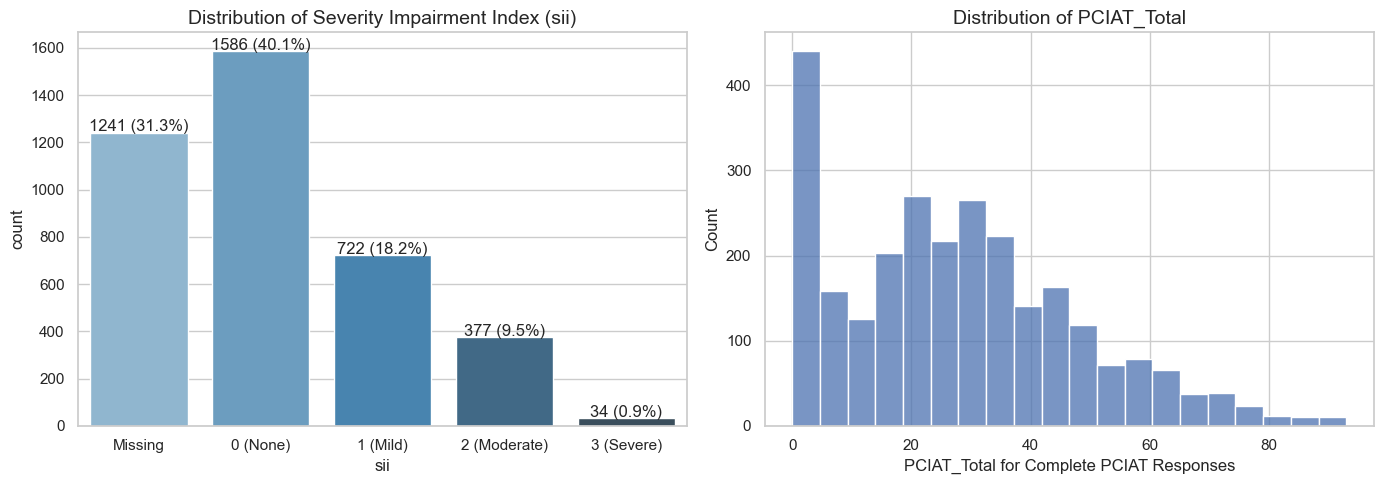

In [22]:
sii_counts['percentage'] = (sii_counts['count'] / total) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SII
sns.barplot(x='sii', y='count', data=sii_counts, palette='Blues_d', ax=axes[0])
axes[0].set_title('Distribution of Severity Impairment Index (sii)', fontsize=14)
for p in axes[0].patches:
    height = p.get_height()
    percentage = sii_counts.loc[sii_counts['count'] == height, 'percentage'].values[0]
    axes[0].text(
        p.get_x() + p.get_width() / 2,
        height + 5, f'{int(height)} ({percentage:.1f}%)',
        ha="center", fontsize=12
    )

# PCIAT_Total for complete responses
sns.histplot(train['complete_resp_total'].dropna(), bins=20, ax=axes[1])
axes[1].set_title('Distribution of PCIAT_Total', fontsize=14)
axes[1].set_xlabel('PCIAT_Total for Complete PCIAT Responses')

plt.tight_layout()
plt.show()

In [23]:
len(train[train['complete_resp_total'] == 0])

307

Note: Apparently, 40% of the participants were not affected by Internet use, 31% were not assessed, and only the minority (~10%) are moderately to severely impaired. There are 307 participants who scored 0 on all PCIAT questions.

### SII by age and sex

In [24]:
assert train['Basic_Demos-Age'].isna().sum() == 0
assert train['Basic_Demos-Sex'].isna().sum() == 0

In [25]:
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,complete_resp_total
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2 (Moderate),55.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0 (None),0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0 (None),28.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1 (Mild),44.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN


In [26]:
def calculate_stats(data, columns):
    if isinstance(columns, str):
        columns = [columns]

    stats = []
    for col in columns:
        if data[col].dtype in ['object', 'category']:
            counts = data[col].value_counts(dropna=False, sort=False)
            percents = data[col].value_counts(normalize=True, dropna=False, sort=False) * 100
            formatted = counts.astype(str) + ' (' + percents.round(2).astype(str) + '%)'
            stats_col = pd.DataFrame({'count (%)': formatted})
            stats.append(stats_col)
        else:
            stats_col = data[col].describe().to_frame().transpose()
            stats_col['missing'] = data[col].isnull().sum()
            stats_col.index.name = col
            stats.append(stats_col)

    return pd.concat(stats, axis=0)

In [27]:
train['Age Group'] = pd.cut(
    train['Basic_Demos-Age'],
    bins=[4, 12, 18, 22],
    labels=['Children (5-12)', 'Adolescents (13-18)', 'Adults (19-22)']
)
calculate_stats(train, 'Age Group')

,count (%)
Age Group,
Children (5-12),2919 (73.71%)
Adolescents (13-18),953 (24.07%)
Adults (19-22),88 (2.22%)


In [28]:
sex_map = {0: 'Male', 1: 'Female'}
train['Basic_Demos-Sex'] = train['Basic_Demos-Sex'].map(sex_map)
calculate_stats(train, 'Basic_Demos-Sex')

,count (%)
Basic_Demos-Sex,
Male,2484 (62.73%)
Female,1476 (37.27%)


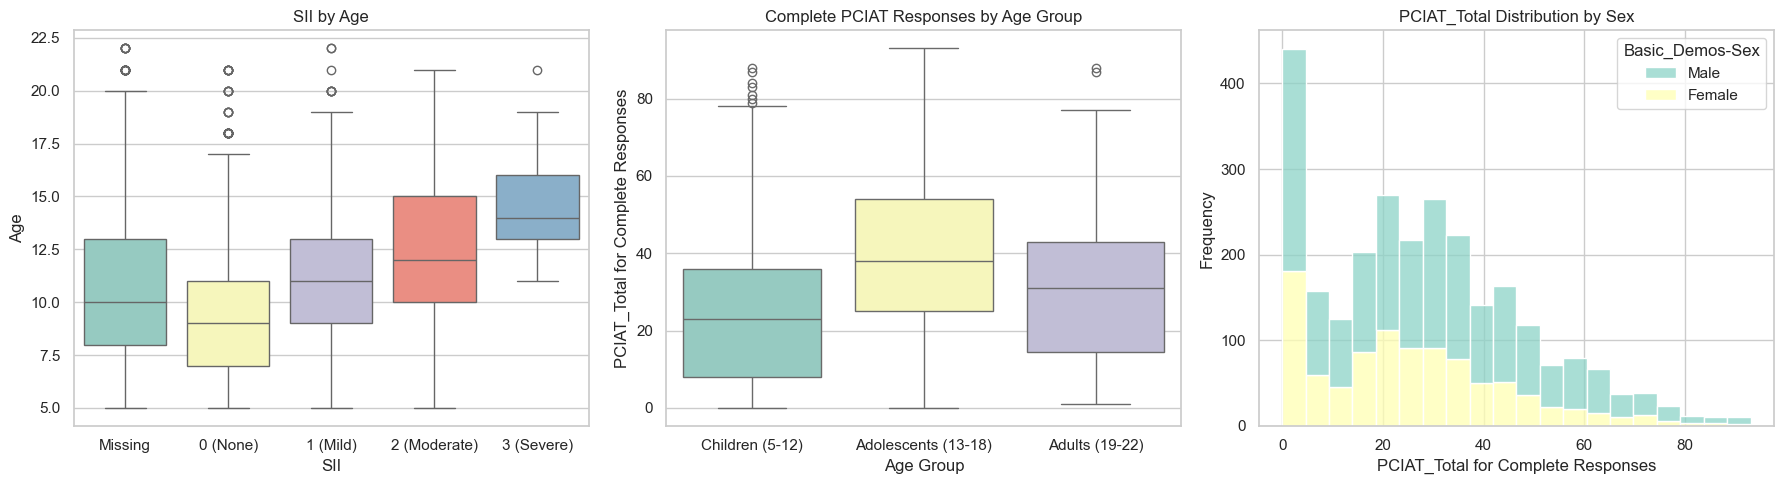

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SII by Age
sns.boxplot(y=train['Basic_Demos-Age'], x=train['sii'], ax=axes[0], palette="Set3")
axes[0].set_title('SII by Age')
axes[0].set_ylabel('Age')
axes[0].set_xlabel('SII')

# Complete PCIAT Responses by Age Group
sns.boxplot(
    x='Age Group', y='complete_resp_total',
    data=train, palette="Set3", ax=axes[1]
)
axes[1].set_title('Complete PCIAT Responses by Age Group')
axes[1].set_ylabel('PCIAT_Total for Complete Responses')
axes[1].set_xlabel('Age Group')

# PCIAT_Total by Sex
sns.histplot(
    data=train, x='complete_resp_total',
    hue='Basic_Demos-Sex', multiple='stack',
    palette="Set3", bins=20, ax=axes[2]
)
axes[2].set_title('PCIAT_Total Distribution by Sex')
axes[2].set_xlabel('PCIAT_Total for Complete Responses')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

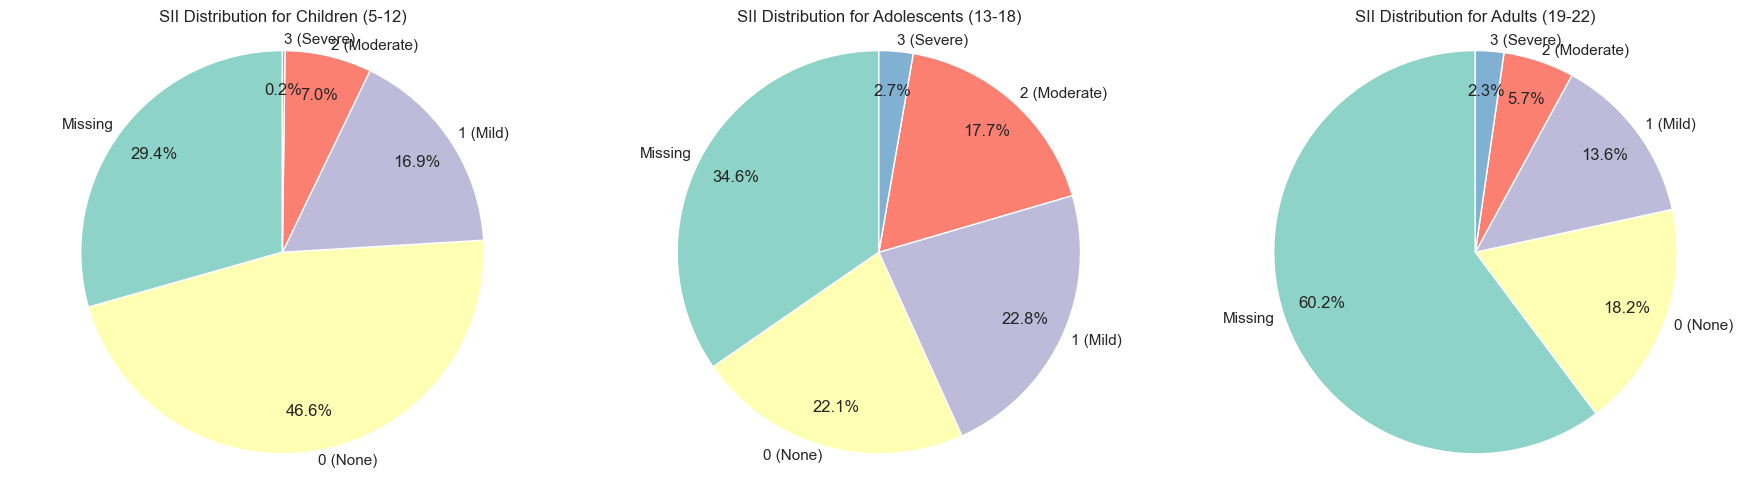

In [30]:
stats = train.groupby(['Age Group', 'sii']).size().unstack(fill_value=0)
fig, axes = plt.subplots(1, len(stats), figsize=(18, 5))

for i, age_group in enumerate(stats.index):
    group_counts = stats.loc[age_group] / stats.loc[age_group].sum()
    axes[i].pie(
        group_counts, labels=group_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("Set3"),
        labeldistance=1.05, pctdistance=0.80
    )
    axes[i].set_title(f'SII Distribution for {age_group}')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

The distribution of sii across different age groups:

In [31]:
stats = train.groupby(['Age Group', 'sii']).size().unstack(fill_value=0)
stats_prop = stats.div(stats.sum(axis=1), axis=0) * 100

stats = stats.astype(str) +' (' + stats_prop.round(1).astype(str) + '%)'
stats

sii,Missing,0 (None),1 (Mild),2 (Moderate),3 (Severe)
Age Group,,,,,
Children (5-12),858 (29.4%),1359 (46.6%),493 (16.9%),203 (7.0%),6 (0.2%)
Adolescents (13-18),330 (34.6%),211 (22.1%),217 (22.8%),169 (17.7%),26 (2.7%)
Adults (19-22),53 (60.2%),16 (18.2%),12 (13.6%),5 (5.7%),2 (2.3%)


Calculate percentages for participants with non-missing SII only:

In [32]:
stats = train[train['sii'] != 'Missing'].groupby(
    ['Age Group', 'sii']
).size().unstack(fill_value=0)
stats_prop = stats.div(stats.sum(axis=1), axis=0) * 100

stats = stats.astype(str) +' (' + stats_prop.round(1).astype(str) + '%)'
stats

sii,Missing,0 (None),1 (Mild),2 (Moderate),3 (Severe)
Age Group,,,,,
Children (5-12),0 (0.0%),1359 (65.9%),493 (23.9%),203 (9.8%),6 (0.3%)
Adolescents (13-18),0 (0.0%),211 (33.9%),217 (34.8%),169 (27.1%),26 (4.2%)
Adults (19-22),0 (0.0%),16 (45.7%),12 (34.3%),5 (14.3%),2 (5.7%)


Note:
- The box plots are different representations of the target variable in it's categorised (SII) and numerical (PCIAT_Total) form. They show that higher SII scores are generally associated with older age groups, but there's considerable overlap in the age ranges within each category, and the median PCIAT_Total is higher in adolescents, suggesting a U-shaped relationship between age and PIU impairment (the peak of Internet-related problems may occur during adolescence).
- Accordingly, in the pie charts, the distribution of SII for children and adults is skewed towards lower values (none and mild), whereas, for adolescents, the distribution is more balanced across the categories of none, mild and moderate.
- But what about the numbers (see tables)? The number of adolescents is much lower than that of children, and the number of adult participants is extremely low (88 in total and only 36 with SII)!
- As we have seen from the graphs in the previous section, the overall distribution of SII is skewed towards lower values and severe cases are rare. So there may be relationships that we cannot see with such unequal sample sizes and under-representation of severe cases.
- The differences between males and females are relatively subtle.

# Internet Use

Internet usage data is crucial to this task because Problematic internet use (PIU), also known as internet addiction or compulsive internet use, refers to excessive and unhealthy use of the internet that interferes with a person’s daily life, responsibilities, and social relationships. The internet usage data provides a direct measure of how much time each participant spends online.

In [33]:
# Internet Use,PreInt_EduHx-computerinternet_hoursday,Hours of using computer/internet,categorical int,"0,1,2,3","0=Less than 1h/day, 1=Around 1h/day, 2=Around 2hs/day, 3=More than 3hs/day"
data = train[train['PreInt_EduHx-computerinternet_hoursday'].notna()]
data.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,complete_resp_total,Age Group
0,00008ff9,Fall,5,Male,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2 (Moderate),55.0,Children (5-12)
1,000fd460,Summer,9,Male,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0 (None),0.0,Children (5-12)
2,00105258,Summer,10,Female,Fall,71.0,Fall,16.648696,56.5,75.6,...,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0 (None),28.0,Children (5-12)
3,00115b9f,Winter,9,Male,Fall,71.0,Summer,18.292347,56.0,81.6,...,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1 (Mild),44.0,Children (5-12)
5,001f3379,Spring,13,Female,Winter,50.0,Summer,22.279952,59.5,112.2,...,1.0,34.0,Summer,40.0,56.0,Spring,0.0,1 (Mild),34.0,Adolescents (13-18)


In [34]:
age_range = data['Basic_Demos-Age']
print(
    f"Age range for participants with measured PreInt_EduHx-computerinternet_hoursday data:"
    f" {age_range.min()} - {age_range.max()} years"
)

Age range for participants with measured PreInt_EduHx-computerinternet_hoursday data: 5 - 22 years


In [35]:
train['PreInt_EduHx-computerinternet_hoursday'].unique()

array([ 3.,  0.,  2., nan,  1.])

In [36]:
param_map = {0: '< 1h/day', 1: '~ 1h/day', 2: '~ 2hs/day', 3: '> 3hs/day'}
train['internet_use_encoded'] = train[
    'PreInt_EduHx-computerinternet_hoursday'
].map(param_map).fillna('Missing')

In [37]:
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,complete_resp_total,Age Group,internet_use_encoded
0,00008ff9,Fall,5,Male,Winter,51.0,Fall,16.877316,46.0,50.8,...,55.0,NaN,NaN,NaN,Fall,3.0,2 (Moderate),55.0,Children (5-12),> 3hs/day
1,000fd460,Summer,9,Male,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,Fall,46.0,64.0,Summer,0.0,0 (None),0.0,Children (5-12),< 1h/day
2,00105258,Summer,10,Female,Fall,71.0,Fall,16.648696,56.5,75.6,...,28.0,Fall,38.0,54.0,Summer,2.0,0 (None),28.0,Children (5-12),~ 2hs/day
3,00115b9f,Winter,9,Male,Fall,71.0,Summer,18.292347,56.0,81.6,...,44.0,Summer,31.0,45.0,Winter,0.0,1 (Mild),44.0,Children (5-12),< 1h/day
4,0016bb22,Spring,18,Female,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN,Adolescents (13-18),Missing


In [38]:
param_ord = ['Missing', '< 1h/day', '~ 1h/day', '~ 2hs/day', '> 3hs/day']
train['internet_use_encoded'] = pd.Categorical(
    train['internet_use_encoded'], categories=param_ord,
    ordered=True
)

train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,complete_resp_total,Age Group,internet_use_encoded
0,00008ff9,Fall,5,Male,Winter,51.0,Fall,16.877316,46.0,50.8,...,55.0,NaN,NaN,NaN,Fall,3.0,2 (Moderate),55.0,Children (5-12),> 3hs/day
1,000fd460,Summer,9,Male,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,Fall,46.0,64.0,Summer,0.0,0 (None),0.0,Children (5-12),< 1h/day
2,00105258,Summer,10,Female,Fall,71.0,Fall,16.648696,56.5,75.6,...,28.0,Fall,38.0,54.0,Summer,2.0,0 (None),28.0,Children (5-12),~ 2hs/day
3,00115b9f,Winter,9,Male,Fall,71.0,Summer,18.292347,56.0,81.6,...,44.0,Summer,31.0,45.0,Winter,0.0,1 (Mild),44.0,Children (5-12),< 1h/day
4,0016bb22,Spring,18,Female,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN,Adolescents (13-18),Missing


In [39]:
calculate_stats(train, 'PreInt_EduHx-Season')

,count (%)
PreInt_EduHx-Season,
Fall,828 (20.91%)
Summer,821 (20.73%)
Winter,906 (22.88%)
NaN,420 (10.61%)
Spring,985 (24.87%)


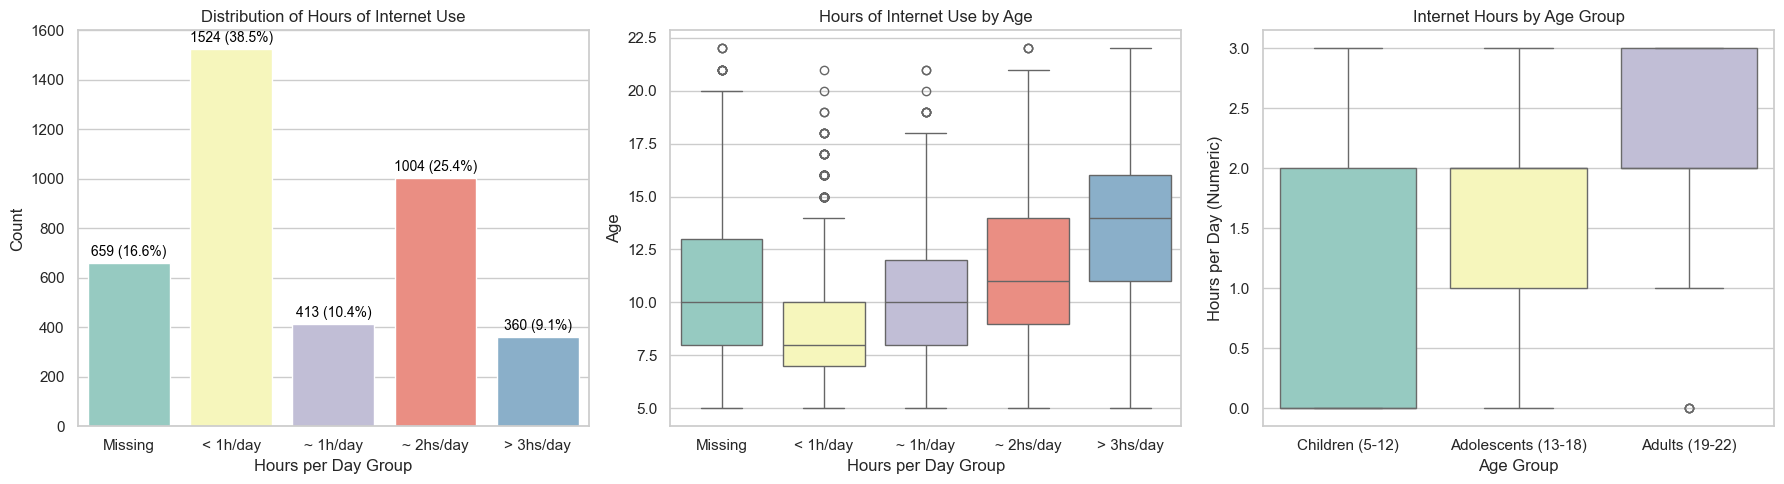

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hours of Internet Use
ax1 = sns.countplot(x='internet_use_encoded', data=train, palette="Set3", ax=axes[0])
axes[0].set_title('Distribution of Hours of Internet Use')
axes[0].set_xlabel('Hours per Day Group')
axes[0].set_ylabel('Count')

total = len(train['internet_use_encoded'])
for p in ax1.patches:
    count = int(p.get_height())
    percentage = '{:.1f}%'.format(100 * count / total)
    ax1.annotate(f'{count} ({percentage})', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), 
                 textcoords='offset points')

# Hours of Internet Use by Age
sns.boxplot(y=train['Basic_Demos-Age'], x=train['internet_use_encoded'], ax=axes[1], palette="Set3")
axes[1].set_title('Hours of Internet Use by Age')
axes[1].set_ylabel('Age')
axes[1].set_xlabel('Hours per Day Group')

# Hours of Internet Use (numeric) by Age Group
sns.boxplot(y='PreInt_EduHx-computerinternet_hoursday', x='Age Group', data=train, ax=axes[2], palette="Set3")
axes[2].set_title('Internet Hours by Age Group')
axes[2].set_ylabel('Hours per Day (Numeric)')
axes[2].set_xlabel('Age Group')

plt.tight_layout()
plt.show()

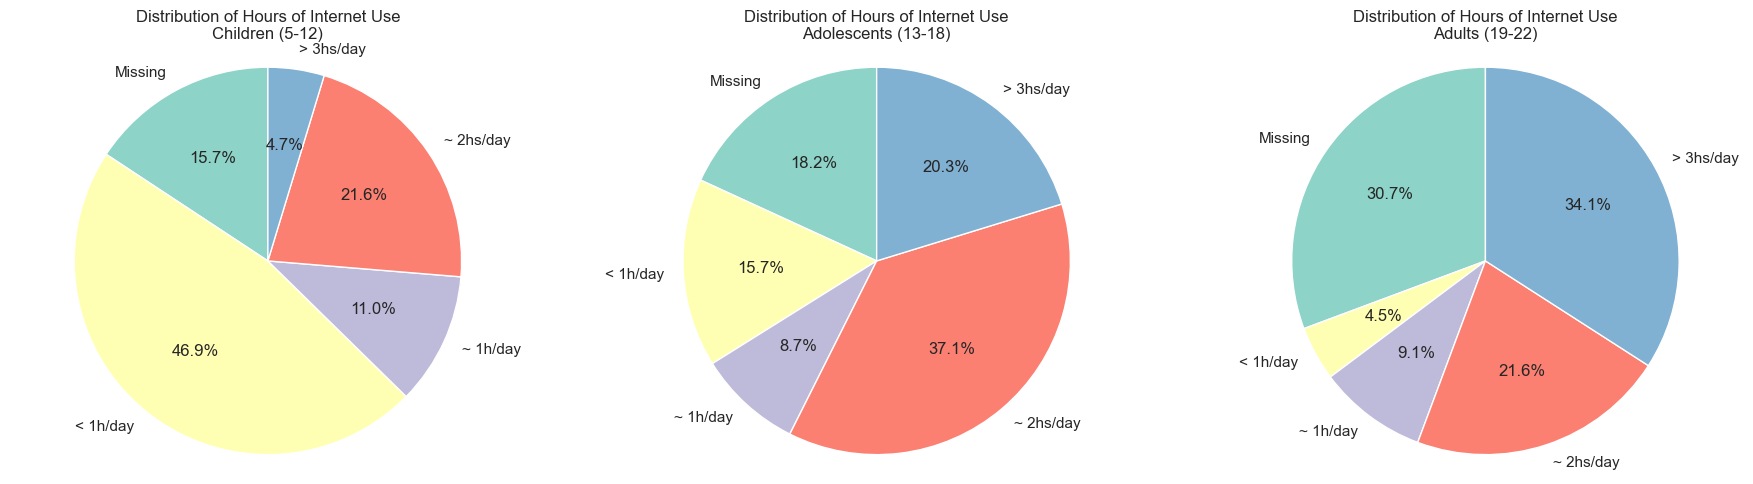

In [41]:
stats = train.groupby(
    ['Age Group', 'internet_use_encoded']
).size().unstack(fill_value=0)
fig, axes = plt.subplots(1, len(stats), figsize=(18, 5))

for i, age_group in enumerate(stats.index):
    group_counts = stats.loc[age_group] / stats.loc[age_group].sum()
    axes[i].pie(group_counts, labels=group_counts.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette("Set3"), labeldistance=1.1)
    axes[i].set_title(f'Distribution of Hours of Internet Use\n{age_group}')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

In [42]:
train_non_na = train.dropna(subset=['PreInt_EduHx-computerinternet_hoursday'])
rows = (train_non_na['PreInt_EduHx-computerinternet_hoursday'] == 3).sum()
print(f"Non-NA Rows - Internet use 3h or more: {(rows / len(train_non_na)) * 100:.2f}%")

rows = (train_non_na['PreInt_EduHx-computerinternet_hoursday'] == 0).sum()
print(f"Non-NA Rows - Internet use 1h or less: {(rows / len(train_non_na)) * 100:.2f}%")

Non-NA Rows - Internet use 3h or more: 10.91%
Non-NA Rows - Internet use 1h or less: 46.17%


In [43]:
stats = train.groupby(['Basic_Demos-Sex', 'internet_use_encoded']
).size().unstack(fill_value=0)
stats_prop = stats.div(stats.sum(axis=1), axis=0) * 100

stats = stats.astype(str) +' (' + stats_prop.round(1).astype(str) + '%)'
stats

internet_use_encoded,Missing,< 1h/day,~ 1h/day,~ 2hs/day,> 3hs/day
Basic_Demos-Sex,,,,,
Female,271 (18.4%),569 (38.6%),139 (9.4%),353 (23.9%),144 (9.8%)
Male,388 (15.6%),955 (38.4%),274 (11.0%),651 (26.2%),216 (8.7%)


Note:
- Internet usage data is missing for 16.6% of participants, while 38.5% reported using the Internet less than hour a day.
- Similar to the SII data, the box plots reveals that higher daily internet usage is associated with older age, with considerable overlap in age ranges within each internet usage category. But here both the categorical and numeric representations of hours spent online indicate a consistent linear relationship.
- The pie charts for age groups are well aligned and shows the same.
- Creating an interaction feature between internet use and age could potentially be useful for modeling.
- Internet use is fairly similar for both sexes.

Internet usage vs SII (target)

Competition description states that the goal is: to detect early indicators of problematic Internet and technology use (PIU), while the definition of PUI includes excessive use of internet.

So let's see how much time the participants with different impairment scores (SII) spent online in this dataset.

In [44]:
sii_reported = train[train['sii'] != "Missing"]
sii_reported.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,complete_resp_total,Age Group,internet_use_encoded
0,00008ff9,Fall,5,Male,Winter,51.0,Fall,16.877316,46.0,50.8,...,55.0,NaN,NaN,NaN,Fall,3.0,2 (Moderate),55.0,Children (5-12),> 3hs/day
1,000fd460,Summer,9,Male,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,Fall,46.0,64.0,Summer,0.0,0 (None),0.0,Children (5-12),< 1h/day
2,00105258,Summer,10,Female,Fall,71.0,Fall,16.648696,56.5,75.6,...,28.0,Fall,38.0,54.0,Summer,2.0,0 (None),28.0,Children (5-12),~ 2hs/day
3,00115b9f,Winter,9,Male,Fall,71.0,Summer,18.292347,56.0,81.6,...,44.0,Summer,31.0,45.0,Winter,0.0,1 (Mild),44.0,Children (5-12),< 1h/day
5,001f3379,Spring,13,Female,Winter,50.0,Summer,22.279952,59.5,112.2,...,34.0,Summer,40.0,56.0,Spring,0.0,1 (Mild),34.0,Adolescents (13-18),< 1h/day


In [45]:
sii_reported.loc[:, 'sii'] = sii_reported['sii'].cat.remove_unused_categories()

In [46]:
stats = sii_reported.groupby(
    ['internet_use_encoded', 'sii']
).size().unstack(fill_value=0)
stats_prop = stats.div(stats.sum(axis=1), axis=0) * 100

stats = stats.astype(str) +' (' + stats_prop.round(1).astype(str) + '%)'
stats

sii,0 (None),1 (Mild),2 (Moderate),3 (Severe)
internet_use_encoded,,,,
Missing,52 (63.4%),15 (18.3%),15 (18.3%),0 (0.0%)
< 1h/day,933 (73.9%),247 (19.6%),78 (6.2%),5 (0.4%)
~ 1h/day,160 (47.2%),123 (36.3%),54 (15.9%),2 (0.6%)
~ 2hs/day,366 (47.2%),251 (32.3%),147 (18.9%),12 (1.5%)
> 3hs/day,75 (29.0%),86 (33.2%),83 (32.0%),15 (5.8%)


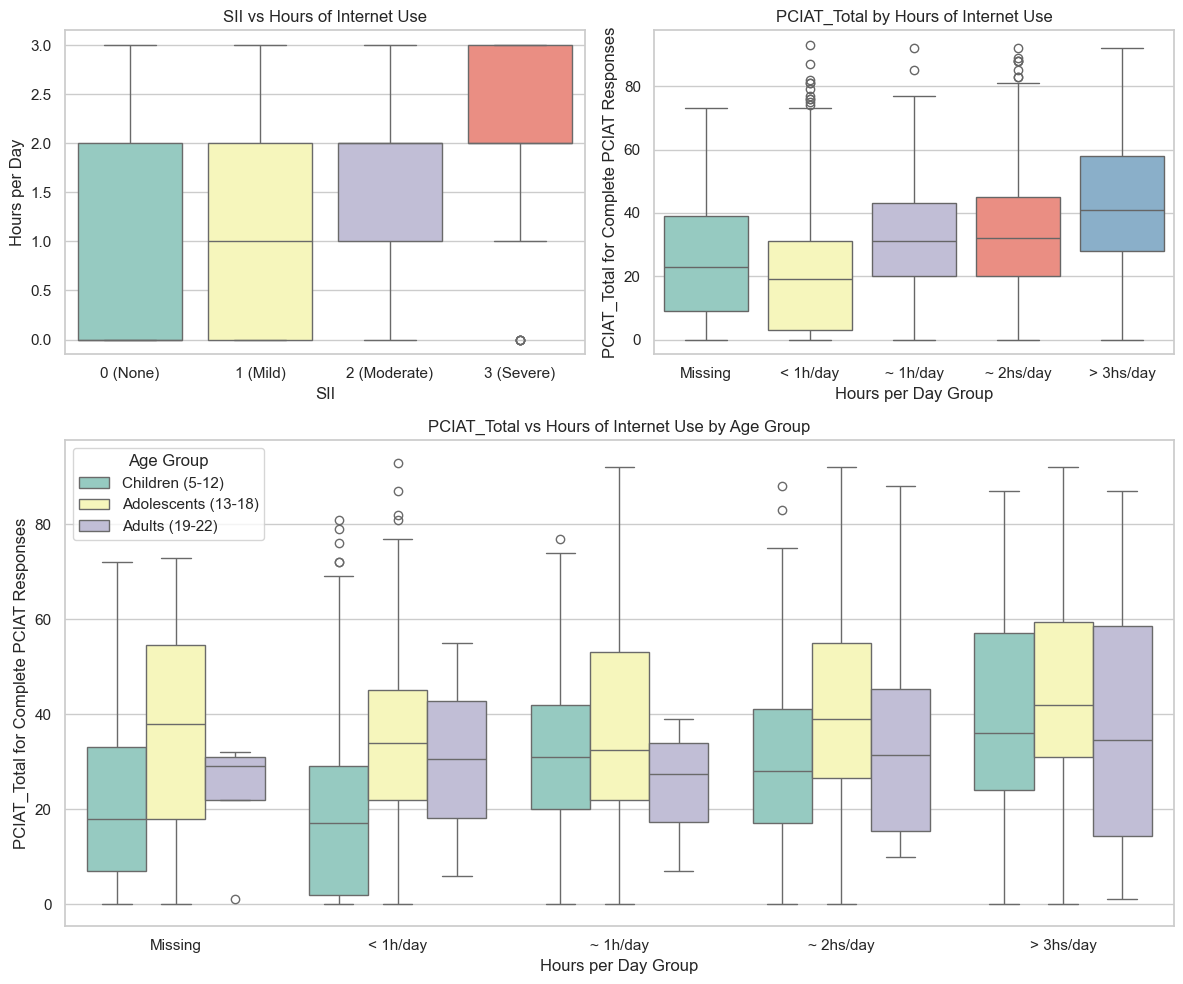

In [47]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])

# SII vs Hours of Internet Use
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(
    x='sii', y='PreInt_EduHx-computerinternet_hoursday',
    data=sii_reported,
    ax=ax1, palette="Set3"
)
ax1.set_title('SII vs Hours of Internet Use')
ax1.set_ylabel('Hours per Day')
ax1.set_xlabel('SII')

# PCIAT_Total for Complete PCIAT Responses by Hours of Internet Use
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(
    x='internet_use_encoded', y='complete_resp_total',
    data=sii_reported,
    palette="Set3", ax=ax2
)
ax2.set_title('PCIAT_Total by Hours of Internet Use')
ax2.set_ylabel('PCIAT_Total for Complete PCIAT Responses')
ax2.set_xlabel('Hours per Day Group')

# SII vs Hours of Internet Use by Age Group (Full width)
ax3 = fig.add_subplot(gs[1, :])
sns.boxplot(
    x='internet_use_encoded', y='complete_resp_total',
    data=sii_reported,
    hue='Age Group', ax=ax3, palette="Set3"
)
ax3.set_title('PCIAT_Total vs Hours of Internet Use by Age Group')
ax3.set_ylabel('PCIAT_Total for Complete PCIAT Responses')
ax3.set_xlabel('Hours per Day Group')

plt.tight_layout()
plt.show()

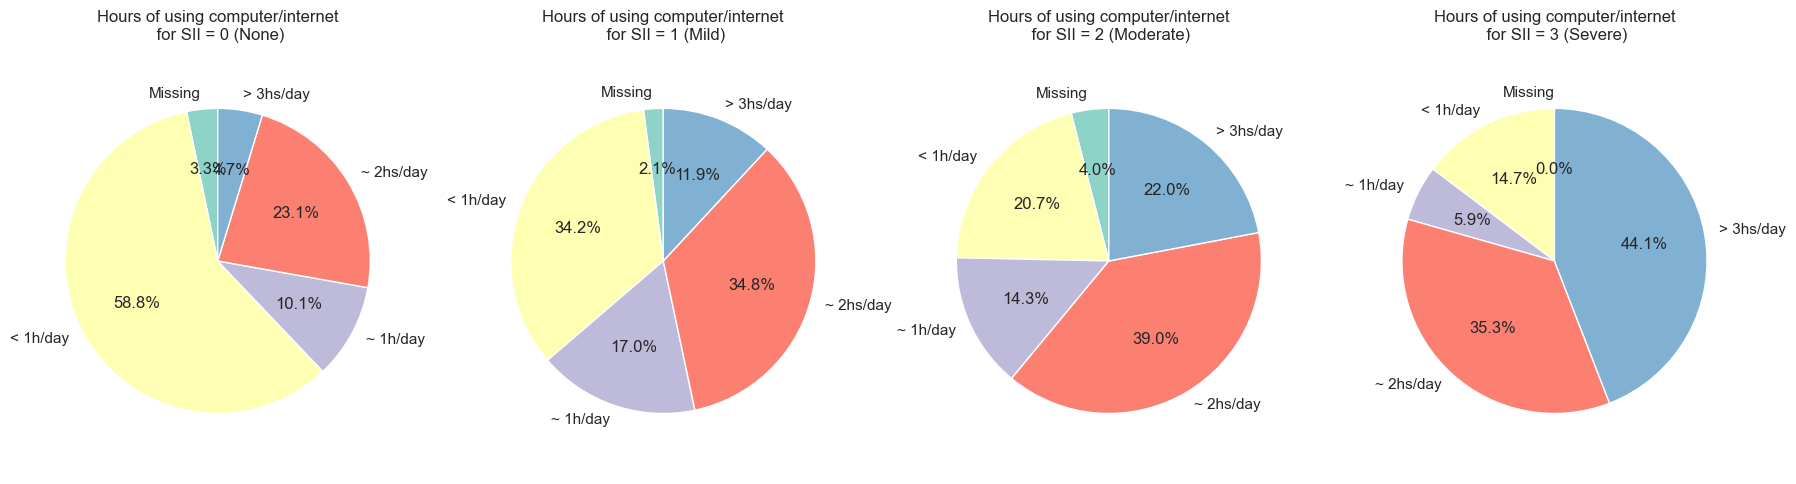

In [48]:
stats = sii_reported.groupby(
    ['sii', 'internet_use_encoded']
).size().unstack(fill_value=0)
fig, axes = plt.subplots(1, len(stats), figsize=(18, 5))

for i, sii_group in enumerate(stats.index):
    group_counts = stats.loc[sii_group] / stats.loc[sii_group].sum()
    axes[i].pie(
        group_counts, labels=group_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("Set3"), labeldistance=1.1
    )
    axes[i].set_title(f'Hours of using computer/internet\n for SII = {sii_group}')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

In [49]:
stats = sii_reported.groupby(
    ['sii', 'internet_use_encoded']
).size().unstack(fill_value=0)
stats_prop = stats.div(stats.sum(axis=1), axis=0) * 100

stats = stats.astype(str) +' (' + stats_prop.round(1).astype(str) + '%)'
stats

internet_use_encoded,Missing,< 1h/day,~ 1h/day,~ 2hs/day,> 3hs/day
sii,,,,,
0 (None),52 (3.3%),933 (58.8%),160 (10.1%),366 (23.1%),75 (4.7%)
1 (Mild),15 (2.1%),247 (34.2%),123 (17.0%),251 (34.8%),86 (11.9%)
2 (Moderate),15 (4.0%),78 (20.7%),54 (14.3%),147 (39.0%),83 (22.0%)
3 (Severe),0 (0.0%),5 (14.7%),2 (5.9%),12 (35.3%),15 (44.1%)


In [50]:
train[
    (train['internet_use_encoded'] == '< 1h/day') & 
    (train['sii'].isin(['2 (Moderate)', '3 (Severe)']))
]['Basic_Demos-Age'].describe()

count    83.000000
mean     10.626506
std       3.083041
min       5.000000
25%       8.500000
50%      10.000000
75%      12.500000
max      21.000000
Name: Basic_Demos-Age, dtype: float64

Note:
- In the box plots, despite the considerable overlap between the different SII and internet use categories, we see a positive trend between PIU impairment and internet use, with people with higher SII scores spending more time online (it would be strange if this wasn't the case, as excessive internet use is assumed by the PIU definition).
- However, when the relationship between PCIAT_Total and hours of Internet use is further broken down by age group (bottom boxplot), the non-linear relationship between age, Internet use and PIU emerges, with adolescents standing out as the most affected age group across all categories of Internet use.
- The pie charts also show that there is a significant proportion of participants (83 in total), of all ages, who spend very little time online (less than 1 hour per day) but have high SII scores (20.7% with SII 2 - moderately impaired and 14.7% with SII = 3 - severely impaired).

Summary of Findings
1. The SII scores tend to increase with age but show a U-shaped relationship, with adolescents having the highest median PCIAT scores.
2. The higher the age, the more hours participants spent online (clear linear trend).
3. People with higher SII scores generally spend more time online, but adolescents stand out as the most affected age group across all categories of internet use.
4. There are participants of almost all ages (5 to 21) who spend less than an hour a day online and have high SII scores.

Note: These results should be interpreted with caution, as there is considerable overlap between the different SII and internet use categories, and severe cases and adults are under-represented in the data.

Interpretation
The relationship between SII and internet usage time is not as straightforward as one might expect, given the definition of PIU (aka internet addiction). This is because factors beyond just the hours spent online contribute to the SII, and the above analysis suggest that the age is particularly crucial: adolescents appear to have the highest SII across all levels of internet use... But how to interpret this: are they more susceptible to PIU, or is this questionnaire just more sensitive to PIU in this age group? Let's try to understand what exacly our target variable reflect.

The questions in the PCIAT questionnaire (used to derive the SII, see data_dict.csv) appear to be designed to measure emotional and social impacts associated with internet use (emotional dependence on the internet, social isolation, neglect of responsibilities, and the impact of internet use on relationships and mood). In other words, the intend was to measure show how problematic the behaviour associated with internet use is. However, parents' perceptions are naturally biased and influenced by various factors - such as their own internet habits, cultural attitudes, or their wishes/ideas about how their children should behave.

Furthermore, can you imagine that spending less than an hour a day online could in itself lead to problems such as emotional distress, neglect of duties or withdrawal from family? I don't think an hour a day of any content on the internet can lead to any of those things... The presence of this in the data only proves that respondents are not being honest in answering the PCIAT questions and internet use, or that SII scores are being influenced by other factors that have nothing to do with the PIU.

The former point out that the single feature that links all the other data we have (physical activity, accelerometer data, sleep, etc.) to internet use (and we need this connection to predict the impact of PIU) may be unreliable and biased as well as the target variable.

The latter imply that participants may have various pre-existing social behaviours or moods that are unrelated to Internet use (and PIU) per se. The questionnaire is a subjective tool, even when completed by parents, while adolescence is an outstanding period in life - a time of identity formation, evolving peer relationships, and a search for independence - all of which can amplify behaviors like mood swings, disobedience, and impulsivity. Consequently, the SII may be capturing how problematic are these broader developmental behaviors rather than internet use specifically.

Additionally, the applicability of the questionnaire across the age range is questionable. I think all the questions in the PCIAT are much more suitable for adolescents. For example:

- A 5-7-year-old may not have household chores, as this depends on cultural norms.
- The question about academic impact may not apply to younger children who are not yet in school or graduated adults.
- Email use and receiving phone calls from "online friends" seem out of context for young children too.
- Questions about reaction to the time allowed to spend on the internet (there are at least 3 of them) are not applicable to adults... usually.

Questions not applicable to a participant’s age could lead to skewed or irrelevant responses. All of these challenges the construct validity of SII and considers whether it accurately measures PIU or is affected by other behavioral factors.

## Features EDA by Groups

Here’s how we can classify types of the features in this dataset:

- Categorical: Variables with discrete categories but no inherent order (represented as strings, e.g., season of enrollment)
- Encoded categorical features (already encoded as integers, e.g. sex)
- Continuous: Variables that can take any value within a range (e.g., age, enmo, heart_rate).
- Ordinal: Variables with a defined order but not necessarily equidistant categories (e.g., questionnaire responses).